# Bayesian Inference I
# Bayesian Inference

This article is part of a series:

- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20I%20-%20Bayesian%20Inference.ipynb">Bayesian Inference I - Bayesian Inference</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20II%20-%20Bayesian%20Linear%20Regression.ipynb">Bayesian Inference II - Bayesian Linear Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20III%20-%20Extending%20Bayesian%20Regression.ipynb">Bayesian Inference III - Extending Bayesian Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20IV%20-%20EBayesian%20Networks%20Discrete.ipynb">Bayesian Inference IV - Discrete Bayesian Networks</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20V%20-%20EBayesian%20Networks%20Continuous%20and%20Hybrid.ipynb">Bayesian Inference V - Continuous and Hybrid Bayesian Networks</a>
- <a href="">Bayesian Inference VI - Generalized Bayesian Networks (under construction)</a>

## Outline

- Two Schools of Thought
- Bayesian Data Analysis
    - Bayes Theorem
    - Conditioning
    - Marginalization
- MLE vs. Maximum a Priori (MAP)
- Model Comparison
    - Bayes Factor
    - Bayesian Information Criterion (BIC)
    - Bayesian p-Values
    - Highest Density Estimate
    - Multiple Comparisons
- Outliers
- Choosing a Prior
    - Conjugate Priors
    - Implementation
    - Empirical Priors
    - Flat Priors
    - Weakly Informative Priors
    - Informative Priors
    - Jeffreys' Priors
    - Zellner's g-Prior
    - Default Prior?
- Prior Predictive Checks
    - Implementation
- Approximate Inference

Welcome to this series on Bayesian inference. As I have a limited amount of experience with it myself, I will largely speak through the words of others, and to some extent, we will be learning together. If the content is too elementary, you may want to skip to the references, or peruse the content of the following experts in the field:

- <a href="http://www.stat.columbia.edu/~gelman/">Andrew Gelman</a>, Professor of Statistics and Political Science at Columbia University
    - <a href="http://www.stat.columbia.edu/~gelman/videos/">Lectures</a>
- <a href="https://users.aalto.fi/~ave/">Aki Vehtari</a>, Professor in Computational Bayesian Modeling at Aalto University (Finland)
- <a href="https://www.eva.mpg.de/ecology/staff/richard-mcelreath/">Richard McElreath</a>, Director of Max Planck Institute for Evolutionary Anthropology, Germany
    - <a href="https://www.youtube.com/watch?v=FdnMWdICdRs">Statistical Rethinking Videos</a>
- <a href="https://betanalpha.github.io/">Michael Betancourt</a>, Freelance Applied Statistician/Physicist
- <a href="https://twiecki.io/">Thomas Wiecki</a>, PyMC Author

<h2 id="two_schools">Two Schools of Thought</h2>

Bayesian inference utilizes a subset of statistical methods that are based on Bayes' Theorem, which describes the probability of an event based on knowledge of conditions related to the event. Whereas frequentist methods focus on the likelihood of observed data under fixed parameters, Bayesian methods can incorporate prior knowledge or beliefs, updating these beliefs in light of new evidence to yield 'posterior' probability distributions. This ability to inject prior beliefs is what some find controversial.

One could argue that the Bayesian analysis becomes subjective, and dependent upon the researcher. But one could also argue that not biasing the outcome, when there is prior knowledge to exploit, is an erroneous bias toward indifference. Perhaps Bayesian statistics is the generalization upon which frequentist statistics should be viewed as a subset.

-----
<i>"Newcomers to Bayesian data analysis are sometimes suspicious of using a prior distribution because they have heard rumors that a presumptuous prior can be smuggled into an analysis and thereby yield any desired posterior distribution. Prior distributions have also been accused of giving unscrupulous analysts extra degrees of freedom for finagling questionable research practices."</i>
- Bayesian Analysis for Newcomers (2017)
-----

One could argue that frequentists make strong assumptions as well. The frequentist approach tends to be heavily reliant upon the Central Limit Theorem, and the degree to which this theorem will practically apply.

-----
<i>"The frequentist approach requires that all probabilities be defined by connection to the frequencies of events in very large samples. This leads to frequentist uncertainty being premised on imaginary resampling of data. Parameters and models cannot have probability distributions, only measurements can."</i>
- Statistical Rethinking (2019)

-----

<i>"Frequentist approaches rely on sampling distributions, illustrated by the cloud of imaginary possibilities... The sampling distribution is defined by the stopping and testing intuitions of the researcher. There, for any fixed set of data, different stopping or testing interactions yield different p-values and confidence intervals. Moreover, confidence intervals have no distributed information."</i>
- The Bayesian New Statistics (2017)
-----

A larger sample size will likely better satisfy the frequentist assumptions, but one can argue that when the sample size is large, finer-pointed questions which segment the data should be asked. A short blog post by Andrew Gelman entitled "N is never enough" reads:

-----
<i>"Sample sizes are never large. If N is too small to get a sufficiently-precise estimate, you need to get more data (or make more assumptions). But once N is "large enough", you can start subdividing the data to learn more (for example, in a public opinion poll, once you have a good estimate for the entire country, you can estimate among men and women, northerners and southerners, different age groups, etc.). N is never enough because if it were "enough" you’d already be on to the next problem for which you need more data."</i>
- N is Never Enough (2005)
-----

Furthermore, the Bayesian approach, which is more complex (though aided by computers), returns a more informative result: a posterior probability distribution, rather than a point estimate. Bayesian methods provide probablistic statements about hypotheses, models, and parameters, making it easier to make probablistic inferences and decisions.

Perhaps these are the two main arguments for Bayesian thinking. If you do not choose your prior, then one is being chosen for you, and if you do choose a prior, the insight returned is richer. Many professors seem to express that Bayesian is simply synonymous with "better", but better in a limited context, because a) it is true the priors can be unreasonably chosen (we'll assume sound judgement going forward), b) because it is more difficult (or intractable) mathematically, and c) because it is more compute-intensive.

Modern technology is overcoming the computational hurdles, and in fact, Bayesian methods have had something to give back to computer science in the sense that such statistical methods can improve the efficiency of optimization algorithms for black-box models, through their ability to account for uncertainty, and thereby make more informed steps toward the optimum.

<h2 id="bayesian_analysis">Bayesian Data Analysis</h2>

### Bayes Theorem

Bayes' Theorem is used to update the probability for a hypothesis, dependent upon related conditions.

$P(A|B) = \frac{P(B|A)(P(A)}{P(B)}$

Nothing is controversial about this mathematical formulation, as it follows directly from the law of conditional probability.

$P(A \cap B) = P(A|B)P(B) = P(B|A)P(A)$

### Conditioning

Assume you have a sample of observations $y_1, \ldots, y_n$ of a random variable $Y \sim f(y|\theta)$, where $\theta$ is a parameter for the distribution. We can consider $\theta$ a random variable as well, and write:</p>

$
f(\theta|y)
= \frac{ f(y|\theta) f(\theta) }{ f(y) }
= \frac{ f(y|\theta) f(\theta) }{ \int f(y|\theta) f(\theta) ~d \theta }
$

$f(\theta|y)$ is the resulting posterior distribution. $f(y|\theta)$ is called the likelihood, and reflects the observed data. $f(\theta)$ is the prior, which multiplies against the likelihood. $f(y)$ is a normalizing constant called the evidence, or marginal likelihood, and though it can be difficult or impossible to compute in practice, we have robust approximation methods. We also often have the option to drop that term and focus on the proportionality of the numerator to the posterior.

$f(\theta|y) \propto likelihood \times prior$

### Marginalization


To make predictions, compute the evidence, or handle nuisance parameters, we marginalize over the parameters. If we have a joint probability distribution $P(X,Y)$, the marginal distribution of $X$ is obtained by summing or interating out $Y$.

- If $Y$is discrete: $P(X) = \sum_y P(X,Y)$

- If $Y$is continuous: $P(X) = \int P(X,Y) ~dY$

Conditioning and marginalization form the backbone of Bayesian data analysis, enabling us to update our knowledge and predictions based on observed data.

<h2 id="mle_vs_map">MLE vs. Maximum a Priori (MAP)</h2>

Density estimation includes selecting a probability distribution function, and the parameters of that function which best explain the joint probability of the observed data. Often, estimating the density is challenging, so we are happy with a point estimate. Two common approaches to this are maximum likelihood estimation (MLE), a frequentist method, and maximum a posteriori (MAP), a Bayesian method.
        
With MLE, the focus is on the data at hand, without considering prior distributions. It aims to maximize the likelihood of observed data given a set of fixed parameters.

$\hat{\theta}_{MLE} = \text{argmax}_{\theta} L(\theta; X) = \text{argmax}_{\theta} \prod_{i=1}^n p(x_i | \theta)$

The Bayesian analog is maximum a priori (MAP) estimation, which seeks to find the parameter values that maximize the likelihood of the posterior distribution. It incorporates both the likelihood of the data and prior beliefs about the distribution and parameters.

$\hat{\theta}_{MAP} = \text{argmax}_{\theta} [ L(\theta;X) p(\theta) ] = \text{argmax}_{\theta} p(\theta | X) = \arg \max_{\theta} \left( \prod_{i=1}^n p(x_i | \theta) p(\theta) \right)$

-----
<i>"Maximum a posteriori (MAP) learning selects a single most likely hypothesis given the data. The hypothesis prior is still used and the method is often more tractable than full Bayesian learning."
- Artificial Intelligence: A Modern Approach (2009)</i>

-----

<i>"The maximum likelihood hypothesis might not be the MAP hypothesis, but if one assumes uniform prior probabilities over the hypothesis then it is."</i>
- Machine Learning (1997)
-----

<i>"The addition of the prior to the MLE can be thought of as a type of regularization of the MLE calculation."</i>
- Probability for Machine Learning (2021)
-----

<h2 id="model_comp">Model Comparison</h2>

Model comparison is a critical aspect of statistical analysis. Bayesian model comparison leverages the entire probability distribution of the data given the model, integrating over parameter values to account for uncertainty comprehensively. Posterior predictive checks are important toward evaluating model fit by comparing observed data to data simulated from the posterior predictive distribution. There is also an array of metrics with frequentist analogs, which speak toward model fit by comparing observed data to data simulated from a posterior predictive distribution.


### Bayes Factors

Bayes factors quantify evidence for one model over another comparing their marginal likelihoods.

$BF = \frac{P(D|M_1)}{P(D|M_2)}$

Harold Jeffreys proposed a scale for their interpretation, with levels of support or strength:

<table class="tableizer-table">
<thead><tr class="tableizer-firstrow"><th>Bayes Factor</th><th>Support</th></tr></thead><tbody>
 <tr><td>1 - 3</td><td>Anecdotal</td></tr>
 <tr><td>3 - 10</td><td>Moderate</td></tr>
 <tr><td>10 - 30</td><td>Strong</td></tr>
 <tr><td>30 - 100</td><td>Very Strong</td></tr>
 <tr><td>>100</td><td>Extreme</td></tr>
</tbody></table>

The frequentist analog would be the likelihood ratio of two different models.

### Bayesian Information Criterion (BIC)

The BIC approximates the marginal likelihood while penalizing model complexity (the number of paramters).

$BIC = -2 ~ln ~P(D|\hat{\theta},M) + k ~ln ~n$

- $\hat{\theta}$ is the maximum likelihood estimate of parameters
- $k$ is the number of parameters
- $n$ is the number of observations

The frequentist analog is the Akaike Information Criterion (AIC)

$AIC = -2 ~ln ~L(\hat{\theta}) + 2k$

- $L(\hat{\theta})$ is the MLE estimate
- $k$ is the number of parameters


### Bayesian p-Values (BPV)

To obtain a Bayesian p-value, a summary statistic $T$, such as the mean, median, or standard deviation, $T_{obs}$ is calculated for the observed data and $T_{sim}$ for the simulated data. We ask "what is the probability that $T_{sim}$ is less than or equal to $T_{obs}$?" If the observed values agree with the predicted ones, the expected value will be $0.5$, meaning that half of the predictions will be below the observations and half will be above.

$BPV = P(T_{sim} \lt P(T_{obs} | Y))$

With frequentist p-values, the p-value is the rate of type I error (false alarms) and the goal of the decision threshold is to limit false alarms. It indicates nothing about the estimated magnitude of parameters, nor how uncertain the estimate is. What is Bayesian about the BPV is that we are not using a sampling distribution, but the posterior predictions distribution; and not a null hypothesis test, but a direct quantification of how well the model explains the data.


### Highest Density Estimate

A convenient way to summarize the uncertainty is with the $95\%$ highest density interval (HDI), or interval of another arbitrary percentage. Although the frequentist CI and Bayesian HDI can have similar numerical limits, the frequentist CI is highly sensitive to the stopping and testing intuitions. By contrast, the Bayesian posterior distribution does not change when the stopping or testing intuitions change because there is no sampling distribution involved.

-----
<i>"The frequentist confidence interval is often misinterpreted as if it were a posterior distribution, because what analysts intuitively want from their analysis is the Bayesian posterior distribution."</i>
- The Bayesian New Statistics (2007)
-----

### Multiple Comparisons

A frequentist would want to correct their p-values and confidence intervals when doing multiple comparisons. When more tests are conducted, the cloud of simulated statistics expands, enlarging the p-value for every test. Bayesian analysis, on the other hand, does not set decision thresholds on the basis of false alarm rates, and instead, considers only the posterior distribution based on actual data. False alarms can occur, but because they are caused by rogue data.


## Outliers

Most traditional models of metric data assume that the data are normally distributed. If the data have severe outliers relative to a normal distribution, conventional practice is to transform the data or to remove the outliers from the data. Transforming data has limitations, and removing data is selecting the data to fit the model. If the outlying values are authentic representations of the underlying population, removing them constitutes selection bias and artifically reduces variances in the data. Bayesian software makes it easy to use non-normal distributions to model the data.

## Choosing a Prior

The need to choose a prior can be anxiety-inducing for the researcher. How conservative is 'objective'? Should it be non-informative or informative? What if the prior is sensible but the model poorly fits the data? Is it cheating to adjust the prior after seeing the data? As one might imagine, there is variation within the popular opinion of the answers to such questions.

-----
<i>"When do I cheat and use too weak a prior, and when do I cheat and use too strong a prior? I cheat and use too weak a prior when I think that my model is pretty simple and the data are strong enough, so I just don't want to have to worry about it... I cheat and use too strong a prior when I think the model might be hard to fit, and I want to really control it and understand what's going on."</i>
- Andrew Gelman, Lecture
-----

Perhaps it would be helpful to give some examples of when the prior is most impactful. The Bayesian method is particularly important when the data is weak, meaning small, which tends to mean noisy. With large N, things converge toward the likelihood given by the data. But if you are performing a small-sample study in a domain in which literature external to your experiment can provide reasonable prior expectations, this prior will help to avoid over-interpreting the data of the small experiment. If you are modeling the times of runners in a race, and have multiple runs as data points for each runner, you may wish to use a hierarchical model in which the prior upon race time given the runner is dependent upon the aggregate trend over runners by time. If conducting a logistic regression where the data suffer complete separation, producing a step function as a curve, a prior will help to regularize such that the model is more realistic.

We tend to want to classify methods as being either objective or subjective. Outside of Bayesian analysis, there is a negative connotation to the latter, but as discussed above, the waters are muddy. Trying to be too objective can land you in subjective territory compared to what to expect from population-level results. At the same time, subjective input can be necessary (particularly with small data) to improve the interpretation of results. How should we think about these concepts? A paper from Andrew Gelman and Christian Hennig argues that the terms objective and subjective should be avoided, and replaced with valid descriptors which actually align with each other more than oppose each other.

-----
<i>"Decisions in statistical analysis are often justified, criticized, or avoided using concepts of objectivity and subjectivity. We argue that the models 'objective' and 'subjective' in statistics discourse are used in a mostly unhelpful way, and we propose to replace each of them with broader collections of attributes; with objectivity replaced by transparency, consensus, impartiality, and correspondence to observable reality, and subjectivity replaced by awareness of multiple perspectives and context dependence. The advantage of these reformulations is that the replacement terms do not oppose each other and that they give more specific guidance about what statistical science strives to achieve."</i>
- Beyond Subjective and Objective in Statistics (2017)
-----

A 2017 paper on offers a list of criteria for choosing and accepting priors:

<ol>
<li>The prior should not be uninformative.</li>
<ul>
<li>That should not be interpreted as calling for massively informative priors, but rather a recognition that complex models, a certain amount of extra information needs to be injected to make useful inferences.</li>
</ul>

</br>
<li>The prior should be aware of the model structure.</li>
<ul>
<li>If a subset of the parameters control a single aspect of the model, the prior on these parameters is set jointly.</li>
</ul>

</br>
<li>When re-using the prior for a different analysis, changes in the problem should be reflected in the prior.</li>

</br>
<li>The prior should limit the flexibility of an overparameterized model.</li>

</br>
<li>Restrictions of the prior to identifiable submanifolds of the parameter space should be sensible.</li>

</br>
<li>The prior should control what a parameter does, rather than its normalized value.</li>

</br>
<li>The prior should be computationally feasible.</li>

</br>
<li>The prior should perform well.</li>
<ul>
<li><i>"It could be that we desire good posterior contraction, asymptotic normality, good predictive performance under mis-specification, robustness against outliers, admissibility in the Stein sense or any other 'objective' property."</i></li>
</ol>

So with all of the above in mind, let's try to specify the main categories of priors that are out there, which I will (somewhat subjectively) characterize as follows:

<ol>
    <li>Conjugate Priors</li>
    <li>Empirical Priors</li>
    <li>Flat Priors</li>
    <li>Weakly Informative Priors</li>
    <li>Informative Priors</li>
</ol>

These range in terms of informativity, which is why 'non-informative' and 'informative' are sort of broad terms. We'll also discuss some more creative priors, including:

6. Jeffreys' Priors
7. Zellman's g-Prior

There are, of course, others that exist in the literature, and research that is ongoing.


### 1. Conjugate Priors

Conjugate priors allow for convenient closed-form calculation. A conjugate prior is a prior which, when combined with a particular likelihood function, yields a posterior distribution that belongs to the same family as the prior, thereby simplifying the mathematical derivation of the posterior. Conjugate-prior relationships include:

#### Beta-Binomial
- Prior: $\theta \sim Beta(\alpha, \beta)$
- Likelihood: $P(D|\theta) - \theta^x (1-\theta)^{n-x}$
- Posterior: $\theta|D \sim Beta(\alpha + x. \beta + n - x)$

#### Gamma-Poisson
- Prior: $\lambda \sim Gamma(\alpha, \beta)$
- Likelihood: $P(D|\lambda) = \frac{\lambda^x e^{-\lambda}}{x!}$
- Posterior: $\lambda \sim Gamma(\alpha + x, \beta + 1)$

#### Normal-Normal (Known Variance)
- Prior: $\mu \sim \mathcal{N}(\mu, \tau^2)$
- Likelihood: $P(D|\mu, \tau^2) \sim \mathcal{N}(\theta, \sigma^2)$
- Posterior: $\mu|\mathbf{y} \sim \mathcal{N} \left( \theta \frac{\sigma^2}{n \tau^2 + \sigma^2} + \bar{y} \frac{n \tau^2}{n \tau^2 + \sigma^2}, \frac{\tau^2 \sigma^2}{n \tau^2 + \sigma^2} \right)$


#### Normal-InverseGamma (Unknown Variance)
- Prior: $\tau \sim Gamma(\alpha, \beta)$
- Likelihood: $P(D|\mu, \tau) \sim \mathcal{N}(\mu, \tau)$
- Posterior: $\tau \sim Gamma \left( \alpha + \frac{n}{2}, \beta + \frac{1}{2} \sum(x_i - \mu \right)$

Conjugate priors satisfy one of the criteria we mentioned above (computationally feasible), but potentially at the expense of not satisfying other criteria. As approximation methods have become more robust, closed-form calculation has become less of a concern.

### Implementation

Let's consider a Bernoulli experiment with a Beta prior that is uniform (the Beta is a generalization of the Uniform). Consider it analogous to an unfair coin flip, as I will set the probability of a positive outcome to 0.4. We'll call upon the <code>beta</code> function of the <code>scipy.stats</code> module to create a Beta distribution (the default parameters of which will result in the Uniform).

Within a loop through experiments of different sample sizes, we will call upon the <code>bernoulli.rvs</code> function of the same module to generate random data, using our pre-specified probability of 0.4 of positive outcome. We will then update the prior, the Beta distribution, to have parameters which reflect a multiplication with the observed likelihood of the experiment. Of course, the result will converge toward the true parameter value as the sample size grows.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from IPython.core.pylabtools import figsize
plt.style.use('seaborn-v0_8-darkgrid')

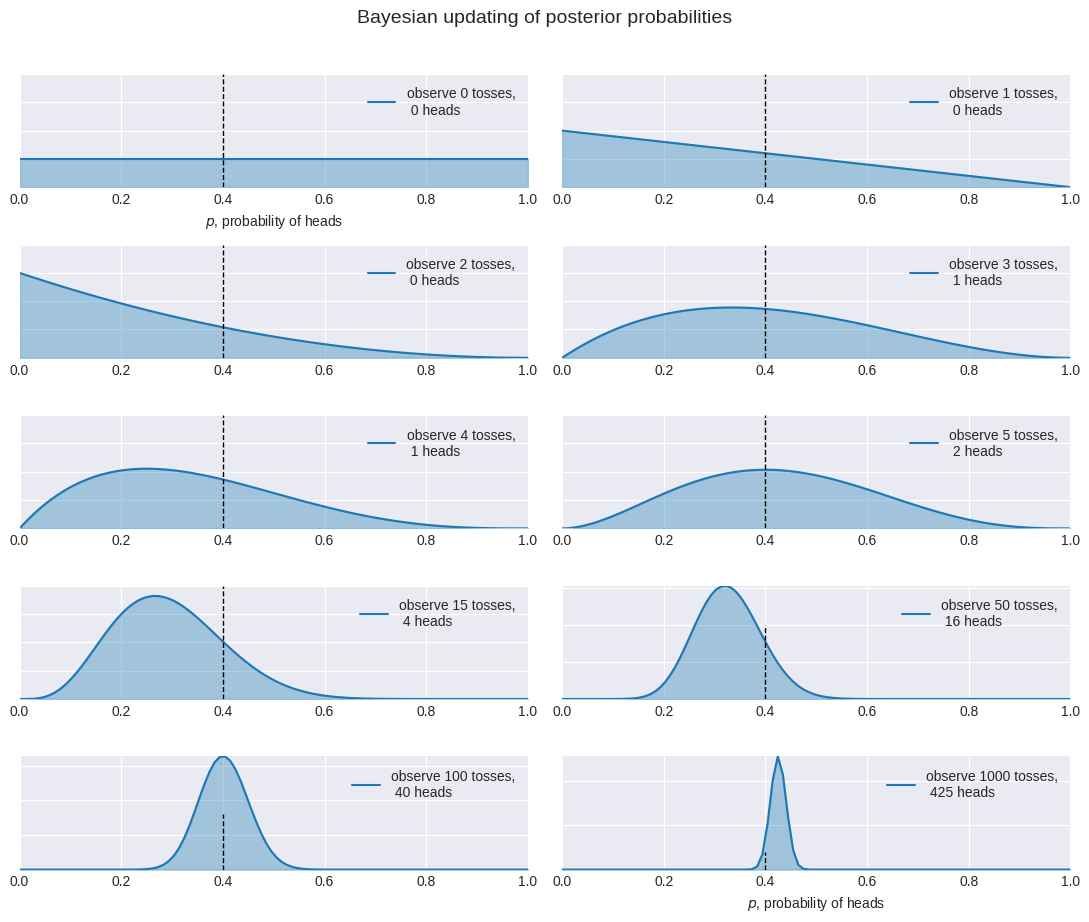

In [2]:
# Adapted from Bayesian Methods for Hackers
# https://dataorigami.net/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/

figsize(11, 9)

import scipy.stats as stats

dist = stats.beta
n_trials = [0, 1, 2, 3, 4, 5, 15, 50, 100, 1000]
data = stats.bernoulli.rvs(0.4, size=n_trials[-1])
x = np.linspace(0, 1, 100)

for k, N in enumerate(n_trials):
    sx = plt.subplot(len(n_trials)//2, 2, k+1)
    plt.xlabel("$p$, probability of heads") \
        if k in [0, len(n_trials)-1] else None
    plt.setp(sx.get_yticklabels(), visible=False)
    heads = data[:N].sum()
    y = dist.pdf(x, 1 + heads, 1 + N - heads)
    plt.plot(x, y, label="observe %d tosses,\n %d heads" % (N, heads))
    plt.fill_between(x, 0, y, color="#348ABD", alpha=0.4)
    plt.vlines(0.4, 0, 4, color="k", linestyles="--", lw=1)

    leg = plt.legend()
    leg.get_frame().set_alpha(0.4)
    plt.autoscale(tight=True)


plt.suptitle("Bayesian updating of posterior probabilities",
             y=1.02,
             fontsize=14)

plt.tight_layout()

### 2. Empirical Priors

Setting a prior based on the data provides results consistent with the data, but is generally thought of as double-dipping upon the likelihood. Though it may seem most 'objective', remember we have clarified objectivity and subjectivity to mean transparency, consensus, impartiality, correspondence to observable reality, awareness of multiple perspectives, and context dependence; and you could argue that many of these criteria are unmet by a data-based prior.

There are, however, compelling arguments that the prior can only be understood in the context of the likelihood (see <a href="http://www.stat.columbia.edu/~gelman/research/published/entropy-19-00555-v2.pdf">this paper</a>), so perhaps 'pure Bayes' (with no peeking) is not necessarily the answer. There is (perhaps arguably) nothing wrong with revising your prior in light of extremely poor fit to the data, if there is logic underlying the adjustment that wasn't initially considered.

-----
<i>"Any prior that isn't fully informative but has any sort of theoretical or practical benefit leans heavily on some aspect of the likelihood. The classic example of this is building priors from the minimalist position, which takes data and a model of the measurement process and considers a prior as little more than an annoying step required to perform a Bayesian analysis. From this perspective, a natural starting point is a noninformative prior. Although it is impossible to define 'noninformative' with any rigor, the general idea is that such a prior affects the information in the likelihood as weakly as possible. In practice, the drive for noninformativity leads to the naive use of uniform distributions as the limit of an infinitely diffuse probability distribution."</i>
- The Prior Can Often Only Be Understood in the Context of the Likelihood (2017)
-----

### 3. Flat Priors

A flat prior is often tempting to those trying to be 'objective', as it would seem to assume no information - a uniform probability across the entire space. There is often justification, however, to use at least weakly informative prior, such as a Normal distribution with wide variance. Flat priors do not actually reflect 'objectivity', however, including the new ways in which we have redefined objectivity. For one thing, they are subject to reparameterization. For example, a flat prior on variance $\sigma^2$ is not a flat prior on standard deviation $\sigma$. This is one of the motivations of Jeffreys' priors, discussed shortly; they are based on the data, but are invariant to reparameterization. Another issue is that, unless your variable is truly suitable to a uniform distribution, you may be allocating too much probability to the most extreme areas within the probability space.

-----
<i>"Non-informative priors are sometimes controversial, and I was told as a student that there is no such thing as a noninformative prior, because if you try to use a uniform distirbution, it would depend on your parameterization... noninformativity is not a pure mathematical property of a prior distribution; non-informativity is relative to the likelihood."</i>
- Andrew Gelman, Lecture (Keynote 2: Weakly Informative Priors)
-----

<p><i>""</i></p>
<i>Why is the prior information contained in a flat prior so useless in our weakly informed regression? Although flat priors are often motivated as being 'non-informative', they are actually quite informative and pull the posterior towards extreme values that can bias our inferences.</i>

<i>To use this, consider a flat prior for the intercept, $\alpha$, and the question of how much prior probability mass is in the interval $-1 \le \alpha \le 1$. Because we can't normalize the prior there is no well-defined answer, but we can at least consider the mass inside the interval relative to the mass outside. There is infinitely more prior mass that pulls inferences outside of the interval than prior mass pulling inferences into the interval.</i>

<i>This logic, however, is exactly the same for the interval $-10 \le \alpha \le 10$, $-100 \le \alpha \le 100$, and in fact any finite interval. The flat prior favors the exterior of any finite interval, pulling the posterior and any resulting inferences toward extreme values.</i></p>
<i>""</i>
- How the Shape of a Weakly Informative Prior Affects Inferences (2017)

-----

### 4. Weakly Informative Priors

Weakly informative priors are often thought of as a sensible default, which let the data speak for themselves.

-----
<i>"Between objective and expert priors lies the realm of 'weakly' informative priors. These priors are constructed by recognizing that while you usually do not have strong prior information about the value of a parameter, it is rare to be completely ignorant... This use of weak prior knowledge is often sufficient to regularize the extreme inferences that can be obtained using maximum likelihood."</i>
- Penalising Model Component Complexity: A Principled, Practical Approach to Constructing Priors (2017)
-----

<i>I think we should use weakly informative priors instead of noninformative or informative priors... another way of saying that is that weakly informative priors are what we already use... you can never be fully non-informative, and even if you think you're being informative then you're not, really..."</i>
- Andrew Gelman, Lecture
-----

Weakly informative priors provide some information, but are not overly restrictive, and are also known as regularizing priors.

-----
<i>"Regularization often takes the form of a term penalizing certain values for the parameters in a model, like too-big coefficients in a regression model. Restricting parameter values is a way of reducing the data a model can represent, thus reducing the chance that a model will capture noise instead of signal. From the Bayesian point of view, Ridge regression can be interpreted as using Normal distributions for the $\beta$ coefficients of a linear model, with a small standard deviation that pushes the coefficients toward zero... on the other hand, Lasso can be interpreted from a Bayesian point of view as the MAP of the posterior computed from a model with Laplace priors for the $\beta$ coefficients."</i>
- Bayesian Analysis with Python (2024)
-----

Weakly informative priors should  rule out unreasonable parameter values but not rule out values that might make sense. The idea is that the loss in precision (by making too weak) is less serious than the gain in robustness. But there are good arguments for not making the prior too diffuse.

-----
<i>"In complex models, however, it typically takes a significant amount of data for the likelihood to be able to identify a necessarily small region of parameter space. The more expensive and sparse the data and the more complex the likelihood, the more informative diffuse priors will be. If we want to make reasonable inferences in these models then we need more principled prior distributions that are actually coherent with our prior beliefs."</i>
- How the Shape of a Weakly Informative Prior Affects Inferences (2017)
-----

### 5. Informative Priors

Informative priors differ from weakly-informative (or non-informative priors) in the amount of influence they exert over the posterior distribution. They are typically based on external data, expert knowledge, or past experience, and typically concentrated around a relatively narrow range. This may be considered the gold standard when the research conditions support it, but there is a risk of negative effect from bias.

### 6. Jeffreys' Priors

Jeffreys' priors are a type of 'objective' prior designed to be non-informative and invariant under reparameterization. They are thought to be particularly useful when no subjective prior information is available, although they do draw the prior in an empirical fashion, based on the data. They are invariant under transformation of parameters (such as variance to standard deviation), which ensures the prior does not depend on the arbitrary choice of parameterization.

Jeffreys' prior is based on the Fisher information matrix $I(\theta)$, which quantifies the amount of information that the observable data provides about the unknown parameter $\theta$. The prior is defined as:

$p(\theta) \propto \sqrt{|I(\theta)|}$

Jeffreys' priors can be improper, meaning they fail to integrate to $1$ over the parameter space.

### 7. Zellner's g-Prior

Zellner's g-Prior is applicable toward regression coefficients in a multiple regression model, and shrinks them to avoid overfitting. The prior for the regression coefficient $\beta$ is:

$\beta|\sigma^2 \sim \mathcal{N}(0, g \sigma^2 (X^TX)^{-1})$

- $g$ is a hyperparameter that controls the amount of shrinkage (pulling coefficients toward zero)

- $\sigma^2$ is the noise variance in the linear regression model

A smaller value of $g$ induces stronger shrinkage.

The posterior distribution of $\beta$ given the data and the prior is also normal.

$\beta|y \sim \mathcal{N} \left( \hat{\beta}, \frac{g}{1+g} \sigma^2 (X^TX)^{-1} \right)$

### Default Prior?

One might ask, is there a one-size-fits-all solution for the majority of problems? The question is too broad for me to rightfully comment, but it is interesting that some of the leading minds on the subject have expressed certain preferences. Andrew Gelman and Michael Betancourt, who I've referenced above, have previously expressed a preference for weakly informative priors. Andrew has more recently expressed a preference for $\mathcal{N}(0,1)$ (upon standardized data, or after scaling). Aki Vehtari has expressed a fondness for $t(3,0,1)$, which has wider tails. Again, don't take any of these to be a panacea, I just think this is interesting enough to mention.

## Prior Predictive Checks

Visualizing prior predictive checks can help to identify oversights and ensure that the range of outcomes considered is within reason. 

### Implementation

Consider the following example in which we use height vs. weight data for a (very large) number of individuals.

In [3]:
import pandas as pd
import arviz as az
import pymc as pm
import xarray as xr
from sklearn.linear_model import LinearRegression

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/pw598/Articles/main/data/SOCR-HeightWeight.csv')
df.head(1)

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925


In [5]:
X = df['Height(Inches)']
y = df['Weight(Pounds)']

Then, standardize the data to make the setting of priors easier (as they should be centered upon zero).

In [6]:
X_std = (X - X.mean()) / X.std()
y_std = (y - y.mean()) / y.std()

The intercept should be centered upon zero, because the data has been centered, and the intercept is the value of y when the x-axis is equal to zero. But I'll give it a wide standard deviation to allow for variation (and for the sake of demonstration).

Without information about what the slope parameter is likely to be, we might also set something like $\mathcal{N}(0,1)$. The results would be as follows:

In [7]:
with pm.Model() as model_1:
    a = pm.Normal("a", 0, 1)
    b = pm.Normal("b", 0, 1)

    mu = a + b * X_std
    sigma = pm.Exponential("sigma", 1)

    pm.Normal("obs", mu=mu, sigma=sigma, observed=y_std)
    idata = pm.sample_prior_predictive(100)

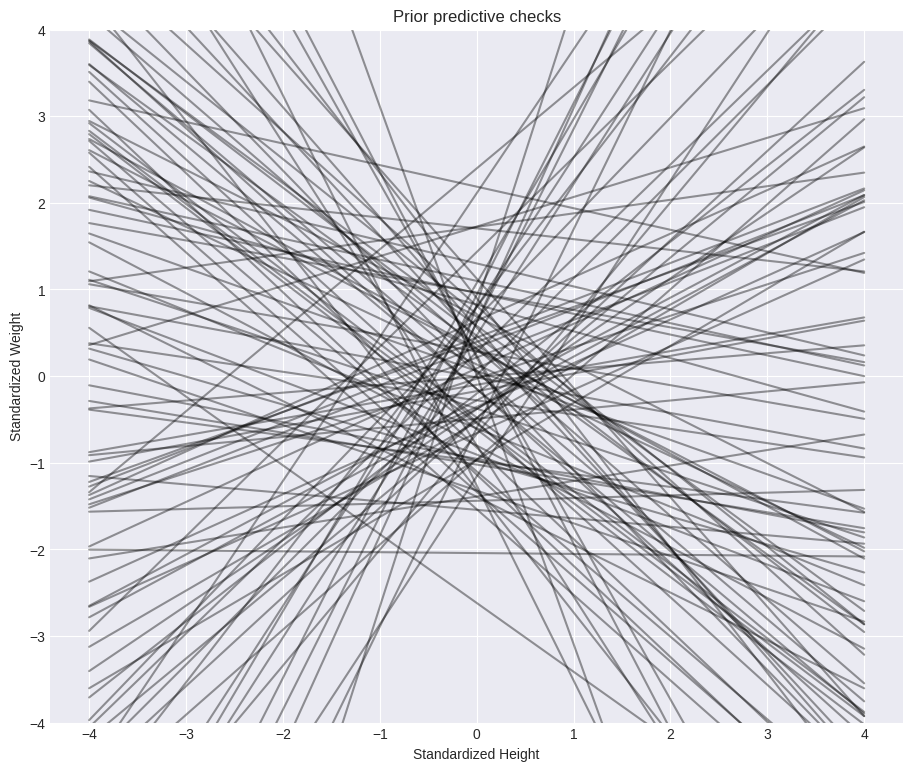

In [8]:
_, ax = plt.subplots()

x = xr.DataArray(np.linspace(-4, 4, 50), dims=["plot_dim"])
prior = idata.prior
y_prior = prior["a"] + prior["b"] * x

ax.plot(x, y_prior.stack(sample=("chain", "draw")), c="k", alpha=0.4)

ax.set_ylim(-4,4)
ax.set_xlabel("Standardized Height")
ax.set_ylabel("Standardized Weight")
ax.set_title("Prior predictive checks");

Clearly, some of these predictions don't seem realistic. Not only do we have downward trends, when it is highly unlikely that increases in height lead to decreases in weight, but many of these trends are practically vertical, which is rarely a witnessed phenomenon in real life.

I think we can do better. If we look at external literature, the slope tends to be around 0.5 when the data is standardized. I'll set the prior mean slope value to this, and use a relatively wide standard deviation of 0.5.

The prior mean intercept value I'll set to zero, and pretending the data isn't centered, I'll use a sigma of 0.25.

In [9]:
with pm.Model() as model_1:
    a = pm.Normal("a", 0, 0.25)
    b = pm.Normal("b", 0.5, 0.5)

    mu = a + b * X_std
    sigma = pm.Exponential("sigma", 1)

    pm.Normal("obs", mu=mu, sigma=sigma, observed=y_std)
    idata = pm.sample_prior_predictive(100)

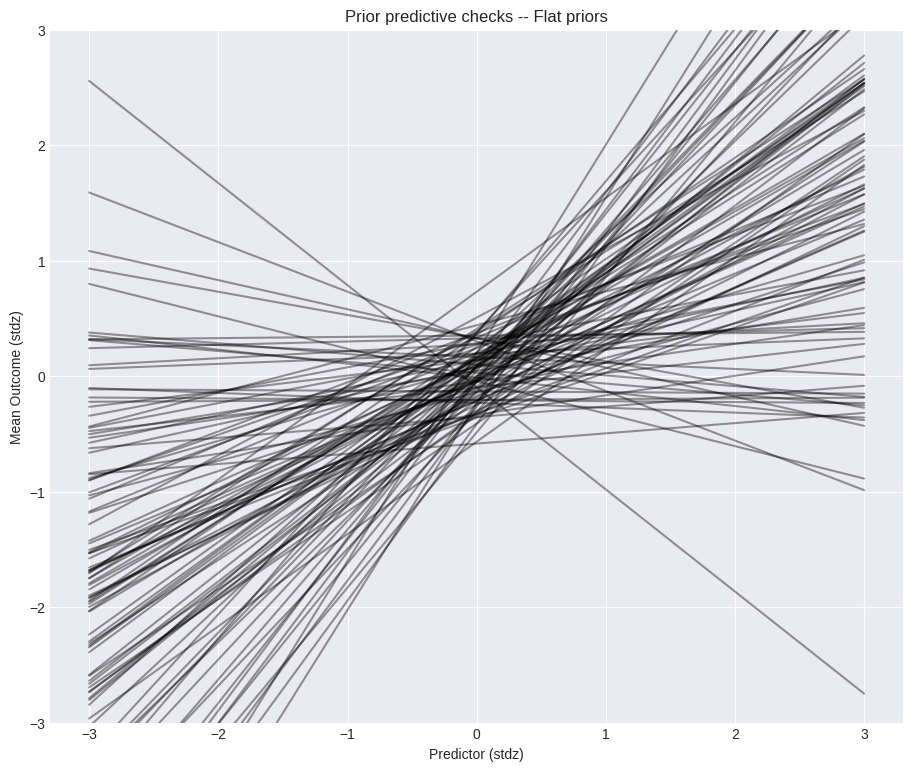

In [10]:
_, ax = plt.subplots()

x = xr.DataArray(np.linspace(-3, 3, 50), dims=["plot_dim"])
prior = idata.prior
y_prior = prior["a"] + prior["b"] * x

ax.plot(x, y_prior.stack(sample=("chain", "draw")), c="k", alpha=0.4)

ax.set_ylim(-3,3)
ax.set_xlabel("Predictor (stdz)")
ax.set_ylabel("Mean Outcome (stdz)")
ax.set_title("Prior predictive checks -- Flat priors");

This looks better. There are still some negative slopes, but I'll allow it so that the upper end of possibilities is not any further restricted. Next, we'll fit the data to the model.

In [11]:
with model_1:
    idata.extend(pm.sample(1000, tune=2000))

Then, sample from the posterior.

In [12]:
with model_1:
    pm.sample_posterior_predictive(idata, extend_inferencedata=True)

We can plot the distribution of the observed data compared to that found by the model parameters using posterior predictive checks:

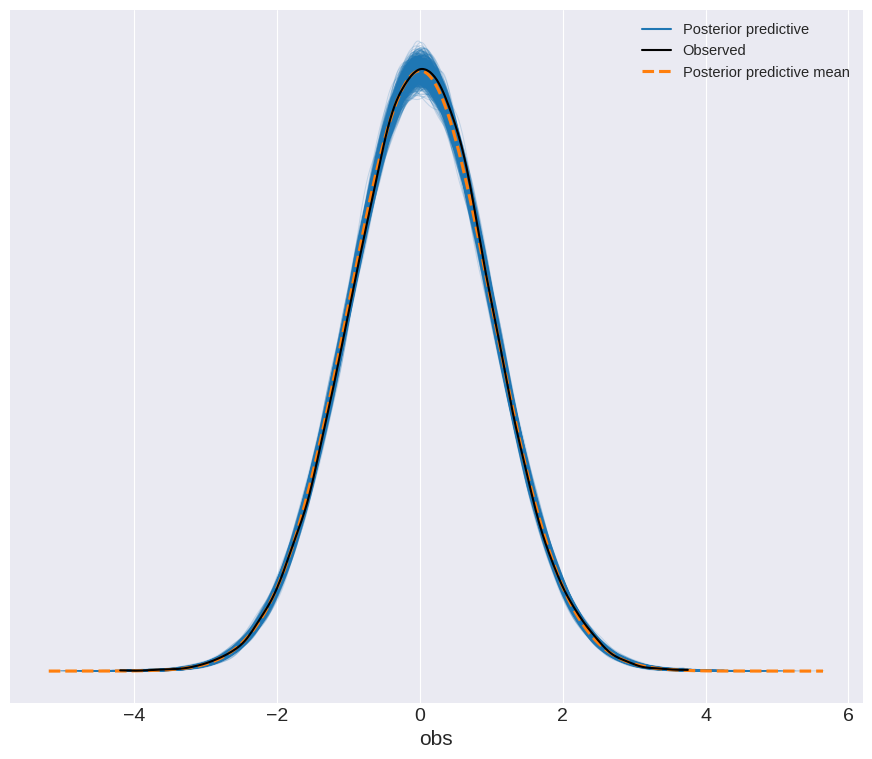

In [13]:
az.plot_ppc(idata, num_pp_samples=1000);

We can plot the trendline and 95% HDI against the data as follows:

In [14]:
post = idata.posterior
mu_pp = post["a"] + post["b"] * xr.DataArray(X_std, dims=["obs_id"])

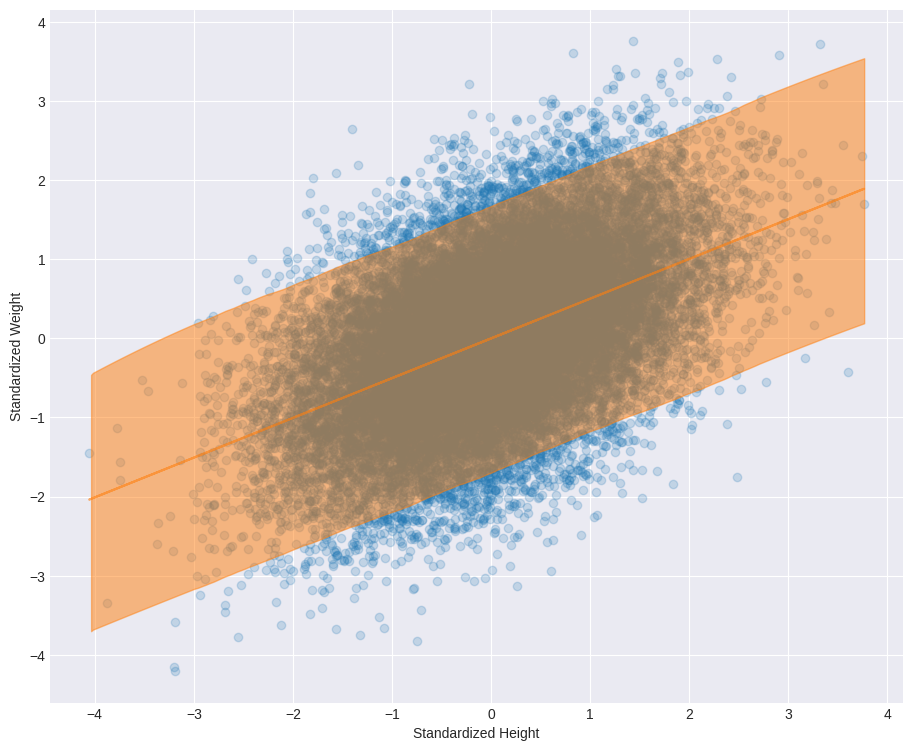

In [15]:
_, ax = plt.subplots()

ax.plot(
    X_std, mu_pp.mean(("chain", "draw")), label="Mean outcome", color="C1", alpha=0.6
)
ax.scatter(X_std, idata.observed_data["obs"], alpha=0.2)
az.plot_hdi(X_std, idata.posterior_predictive["obs"], hdi_prob=0.95)

ax.set_xlabel("Standardized Height")
ax.set_ylabel("Standardized Weight");

There are a lot of data points, so we should find that a MLE based technique performs similarly.

In [16]:
from sklearn.linear_model import LinearRegression

X_std_reshaped = np.array(X_std).reshape(-1,1)
y_std_reshaped = np.array(y_std).reshape(-1,1)

model = LinearRegression()
model_fit = model.fit(X_std_reshaped, y_std_reshaped)

In [17]:
np.mean(post["a"])

<xarray.DataArray 'a' ()> Size: 8B
array(3.10938936e-05)

In [18]:
np.mean(post["b"])

<xarray.DataArray 'b' ()> Size: 8B
array(0.50262131)

In [19]:
print(model_fit.intercept_[0])
print(model_fit.coef_[0][0])

-4.412368546300279e-15
0.502858520602844


We see that the Bayesian model's intercept is essentially zero, and that the slope is 0.502621 (I haven't set a random seed, so this can change if the posterior is recalculated). Similarly, the sklearn model's intercept is essentially zero, and the slope is 0.502859.

## Approximate Inference

Markov Chain Monte Carlo (MCMC) methods generate samples from a probability distribution by constructing a Markov chain that has the desired distribution as its equilibrium. The idea is to design a Markov chain whose states correspond to possible values of the variable being sampled, and whose stationary distribution is the target distribution. Hamiltonian Monte Carlo (HMC) leverages concepts from physics, using gradient information about the target distribution to explore the parameter space more efficiently. No-U-Turn Sampling (NUTS) is a popular form of HMC that further enhances efficiency and usability by automatically adjusting the trajectory length and step size.

-----
<i>"For many distributions of scientific interest, the normalizing constant in the PDF or PMF is unknown and beyond the reach of closed-form computation... The Metropolis-Hastings algorithms offer a general recipe that lets us start with any irreducible Markov chain on the state spaces of interest and then modify it into a Morkov chain that has the desired stationary distribution... Moves are proposed according to the original chain, but the proposal may or may not be accepted... How to choose a good proposal distribution is a complicated topic..."</i>
- Introduction to Probability (2019)
-----

<i>"To draw samples from the distribution... MCMC starts with an initial guess... MCMC is then used to produce a chain of new samples from this initial guess. First, a proposal for the new sample is created by adding a small random perturbation to the most recent sample. Second, the proposal is either accepted as the new sample, or rejected... There are many ways of adding random noise to create proposals, and different approaches to the process of accepting and rejecting."</i>
- A Simple Introduction to Markov Chain Monte–Carlo Sampling (2018)
-----

The width of the proposal distribution can be considered a tuning parameter of the algorithm. Initial samples are typically ignored as they might be very wrong, because of the issues of chain convergence and sampling burn-in. Starting points that are closer to the mode of the posterior distribution will ensure a faster burn-in phase, and fewer problems with convergence.

Typically, we treat MCMC as a black box (as Thomas Wiecki calls it, the 'magic inference button'), but we should run diagnostic tests such as examining trace plots, to ensure that the multiple chains have converged upon the same center and variability for each parameter. You may want to adjust parameters, such as the number of draws or target acceptance rate, if experiencing a lack of convergence.

The next two articles, in which we'll do much more coding, are about Bayesian regression. Following that is a series of articles on Bayesian networks.

## References

- Davidson-Pilon, C. Bayesian Methods for Hackers. https://dataorigami.net/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/#contents

- Kruschke, J. K., & Liddell, T. M. (2017). The Bayesian New Statistics. Psychonomic Society. https://doi.org/10.3758/s13423-016-1221-4

- Martin, O. (2024). Bayesian Analysis with Python (3rd ed.). Packt. https://www.packtpub.com/en-ca/product/bayesian-analysis-with-python-9781805127161

- Martin, O. A., Kumar, R., & Lao, J. (2021). Bayesian Modeling and Computation in Python. CRC Press. https://doi.org/ISBN 978-0-367-89436-8

- Gelman, A., Carlin, J., Stern, H., Rubin, D., Dunson, D., & Vehtari, A. (1995). Bayesian Data Analysis (3rd ed.). https://www.researchgate.net/publication/46714374_Bayesian_data_analysis

- McElreath, R. (2017). Statistical Rethinking (2nd ed.). https://github.com/Booleans/statistical-rethinking/blob/master/Statistical%20Rethinking%202nd%20Edition.pdf

- (2005, July 31). N is never large. Statistical Modeling, Causal Inference, and Social Science. https://statmodeling.stat.columbia.edu/2005/07/31/n_is_never_larg/

- Gelman, A., & Hennig, C. (2017). Beyond subjective and objective in statistics. Columbia University. http://www.stat.columbia.edu/~gelman/research/published/objectivityr5.pdf

- Gelman, A., Simpson, D., & Betancourt, M. (2017). The Prior Can Often Only Be Understood in the Context of the Likelihood. Entropy.

- Betancourt, M. (2017). How the Shape of a Weakly Informative Prior Affects Inferences. https://mc-stan.org/users/documentation/case-studies/weakly_informative_shapes.html

- Simpson, D., Rue, H., Riebler, A., Martins, T. G., & Sørbye, S. H. (2016). Penalising Model Component Complexity: A Principled, Practical Approach to Constructing Priors. Statistical Science. https://arxiv.org/abs/1403.4630

- Blitzstein, J. (2019). Introduction to Probability (2nd ed.). Harvard University and Stanford University. https://drive.google.com/file/d/1VmkAAGOYCTORq1wxSQqy255qLJjTNvBI/view

- Barber, D. (2007). Bayesian Reasoning and Machine Learning. http://web4.cs.ucl.ac.uk/staff/D.Barber/textbook/270212.pdf

- Kruschke, J. K., & Liddell, T. M. (2017). Bayesian data analysis for newcomers. Psychonomic Society. https://doi.org/10.3758/s13423-017-1272-1

- Salvatier, J., Wiecki, T. V., & Fonnesbeck, C. (2015). Probabilistic Programming in Python using PyMC. https://arxiv.org/pdf/1507.08050v1

- Van de Schoot et al., R. Bayesian statistics and modelling. Nature. https://doi.org/10.1038/ s43586-020-00001-2

- Abril-Pla, O. et al. (2023). PyMC: A modern, and comprehensive probabilistic programming framework in Python. PeerJ. https://doi.org/10.7717/peerj-cs.1516

- Orduz, J. (2013). Introduction to Bayesian Modeling with PyMC3. https://juanitorduz.github.io/intro_pymc3/

- S, O. (n.d.). Full Explanation of MLE, MAP and Bayesian Inference. https://towardsdatascience.com/full-explanation-of-mle-map-and-bayesian-inference-1db9a7fb1d2b
